In [ ]:
import specpolFlow as pol
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.gridspec import GridSpec


In [3]:
name = 'hd218440_E_1734576pnm_rn.s'
# Object name
obsname = name.split('_rn')[0]

# Folder containing the saved models
folder = Path(r"G:\Shared drives\BinamicsOstars\TLUSTY Models") / obsname
obs_folder = Path(r"G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero")

# Load saved models
spec1 = pol.read_spectrum(obs_folder/name)
binary_model = pol.read_spectrum(folder / "binary_model.s")
single_model = pol.read_spectrum(folder / "single_model.s")

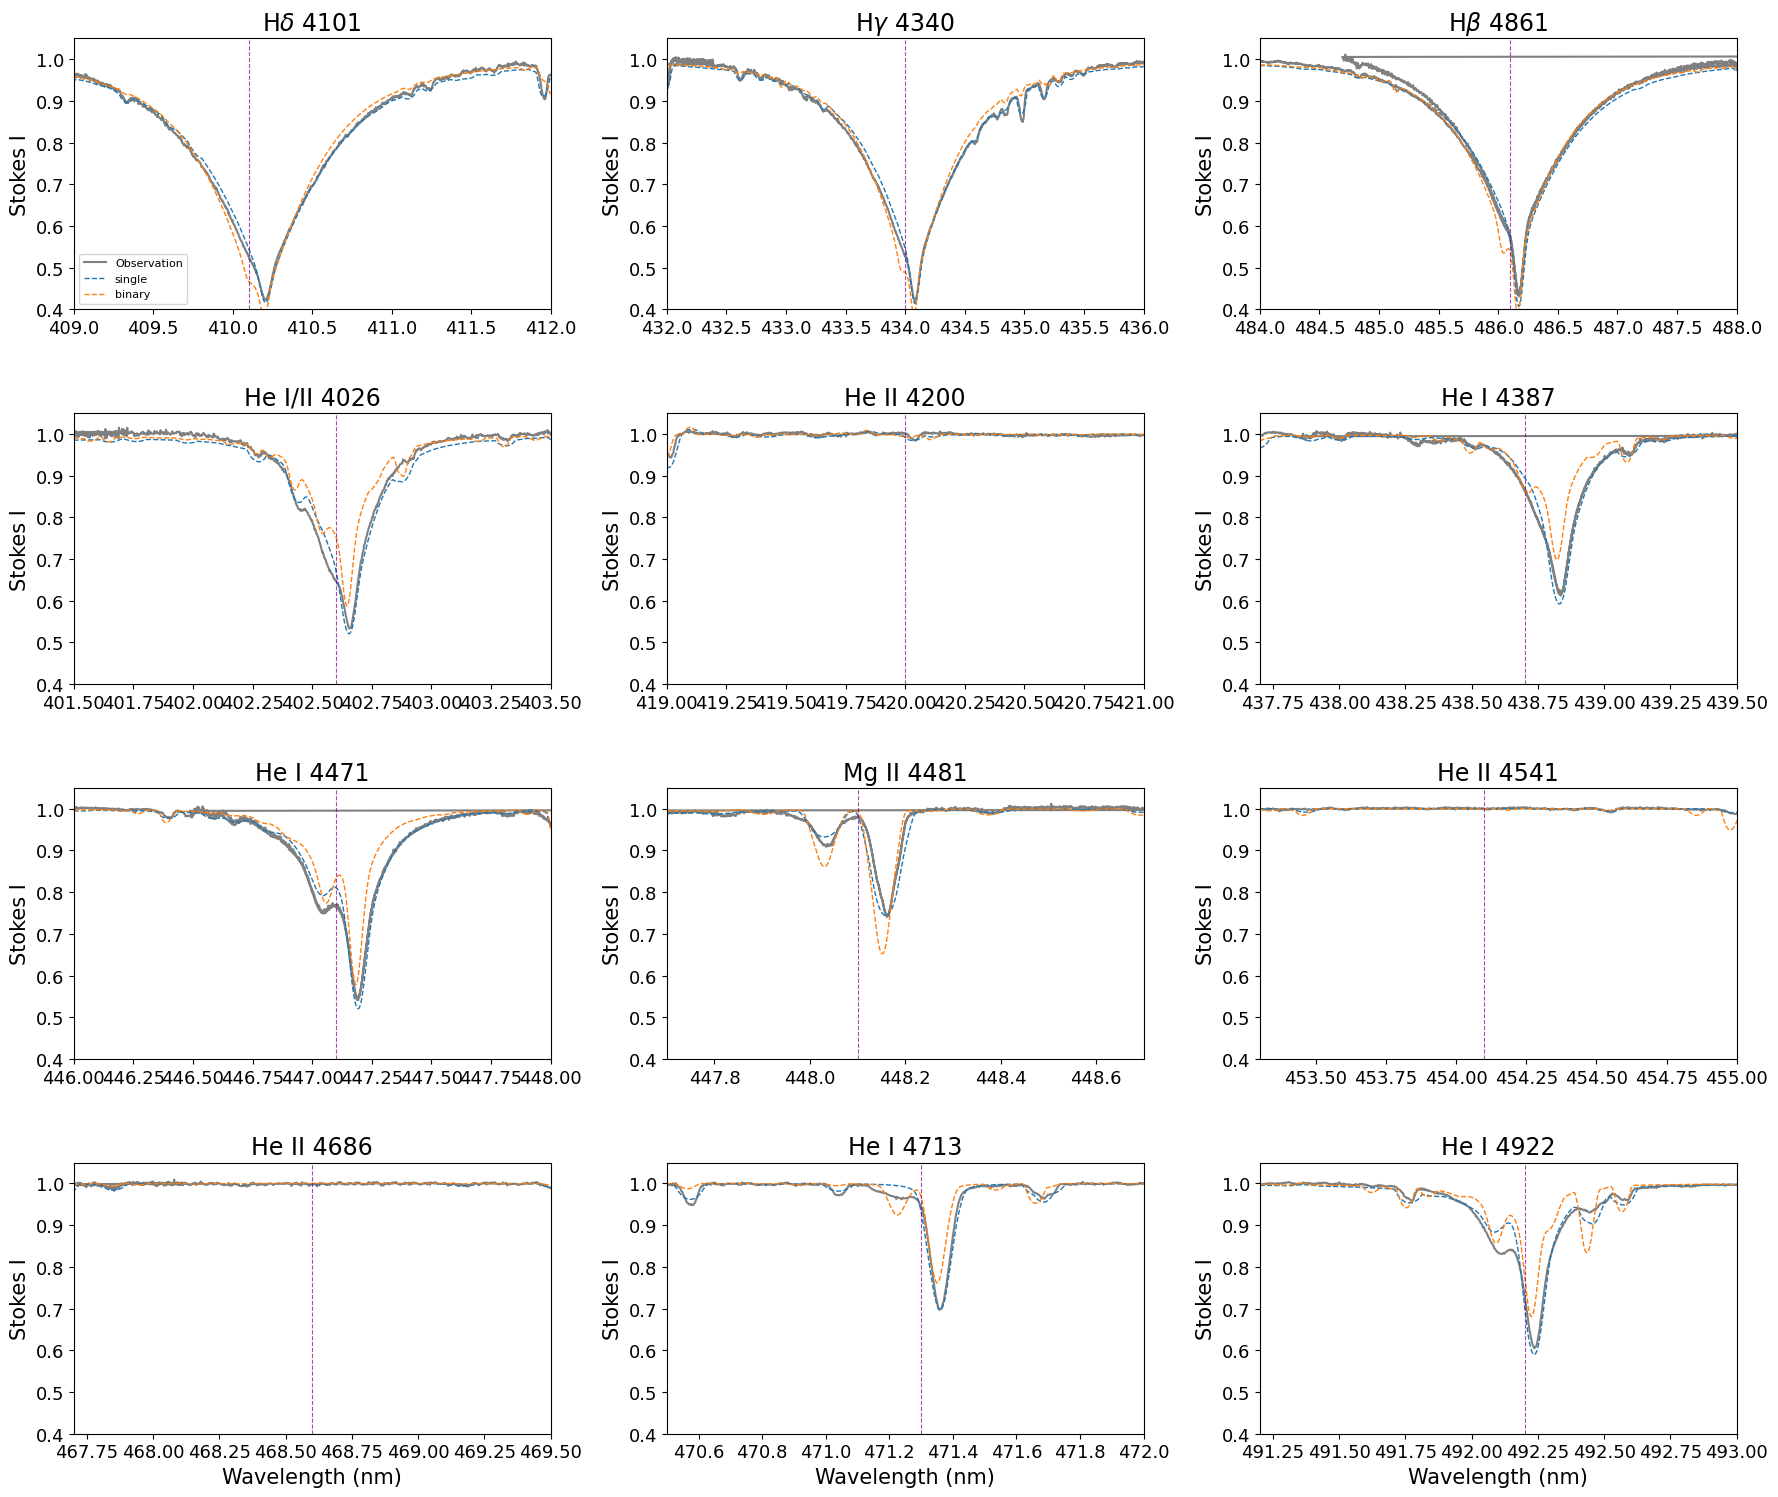

In [10]:
# =========================
# LINE DIAGNOSTIC PLOT
# =========================

H_lines = [(409,412,410.1,r"H$\delta$ 4101"), (432,436,434.0,r"H$\gamma$ 4340"),
           (484,488,486.1,r"H$\beta$ 4861")]

He_lines = [(401.5,403.5,402.6,"He I/II 4026"), (419,421,420.0,"He II 4200"),
            (437.7,439.5,438.7,"He I 4387"), (446,448,447.1,"He I 4471"),
            (447.7,448.7,448.1,"Mg II 4481"), (453.3,455,454.1,"He II 4541"),
            (467.7,469.5,468.6,"He II 4686"), (470.5,472,471.3,"He I 4713"),
            (491.2,493,492.2,"He I 4922")]

fig, ax = plt.subplots(4,3,figsize=(18,16))
all_lines = H_lines + He_lines

for a, (xmin,xmax,wl,line) in zip(ax.flat,all_lines):
    a.plot(spec1.wl,spec1.specI,color="0.5",lw=1.5,label="Observation")
    a.plot(single_model.wl,single_model.specI,lw=1,ls="--",label="single")
    a.plot(binary_model.wl,binary_model.specI,lw=1,ls="--",label="binary")

    a.axvline(wl,color="purple",ls="--",lw=0.8,alpha=0.7)
    a.set_xlim(xmin,xmax); a.set_ylim(0.4,1.05)
    a.set_title(line); a.set_ylabel("Stokes I")

for a in ax[-1]: a.set_xlabel("Wavelength (nm)")

ax[0,0].legend(fontsize=8)
plt.tight_layout(rect=[0,0,1,0.95],h_pad=2.5)
plt.show()